# PSTU DataThon 2026 Vol 1 — Enhanced EDA & Feature Pruning

Analyze the training data, detect unnecessary / duplicate columns, and produce a clean, reduced feature set that downstream models (LightGBM, XGBoost, CatBoost, MLP) can consume.

**Inputs**
- `train.csv` — ~60.6k rows x 350 anonymized numerical features + `TARGET`
- `test.csv`  — ~75.8k rows + extra `id` column

**What this notebook does**
1. Loads `train.csv` / `test.csv` with memory-efficient dtypes.
2. Profiles each column: dtype, missingness, cardinality, statistics, near-constant detection.
3. Identifies **categorical-like** columns (the `feat_142 / 157 / 318 / 320 / 325 / 337` set) with prefix-aware labels (`PRD_`, `PRV_`, `PERF_`, `CH_`, `SEG_`, `OFC_`).
4. Computes **Pearson** and **Spearman** correlations on numeric features; reports top |corr| pairs.
5. Detects **duplicate columns** (exact duplicates) and **near-duplicate columns** (|corr| > 0.999).
6. Detects **redundant columns** in two passes:
   - High pairwise correlation (|Pearson| >= 0.95) — keep one representative per cluster.
   - Target-uncorrelated columns (|point-biserial| < 0.005) — drop them as noise.
7. Saves the reduced feature list to `enhanced_features.json` for downstream notebooks.

**Outputs**
- `enhanced_features.json` — `{kept_features, dropped_constant, dropped_dup, dropped_highcorr, dropped_uncorr, cat_cols, num_cols}`.
- `enhanced_corr_top.csv` — the top |corr| pairs for human inspection.
- `enhanced_dtypes.parquet` — memory-efficient cast of train (np.float32 + category dtypes).


## 1. Imports & Configuration


In [17]:
import os, gc, json, time, warnings, hashlib
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
pd.set_option('display.max_rows', 200)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')

from scipy.stats import pearsonr, spearmanr, pointbiserialr

DATA = r'd:\DS\kaggle\PSTU_Datathon'
SEED = 42
np.random.seed(SEED)

# Thresholds (centralized so downstream notebooks can stay aligned)
CORR_HIGH  = 0.95   # |Pearson| >= this -> near-duplicate cluster
CORR_DUP   = 0.999  # |Pearson| >= this -> treat as exact duplicate
CORR_UNCORR = 0.005 # |corr w/ TARGET| < this -> drop as noise
MISSING_DROP = 0.95 # drop columns with >= 95% missing
CONSTANT_DROP = 0.999  # drop columns where one value occupies >= 99.9% of rows

print('pandas:', pd.__version__)
print('numpy :', np.__version__)
t0 = time.time()
print(f'Config OK ({time.time()-t0:.2f}s)')


pandas: 2.3.3
numpy : 2.2.6
Config OK (0.00s)


## 2. Load Data


In [18]:
t0 = time.time()
# Two passes: first sample to learn dtypes, then full load with explicit dtypes.
raw_train = pd.read_csv(f'{DATA}\\train.csv')
raw_test  = pd.read_csv(f'{DATA}\\test.csv')
print(f'loaded train={raw_train.shape}, test={raw_test.shape}  in {time.time()-t0:.1f}s')
print(f'train mem: {raw_train.memory_usage(deep=True).sum()/1e6:.1f} MB')
print(f'test  mem: {raw_test.memory_usage(deep=True).sum()/1e6:.1f} MB')

print('\n--- train head (first 5 cols / 3 rows) ---')
display(raw_train.iloc[:3, :5])
print('\n--- train target balance ---')
print(raw_train['TARGET'].value_counts(normalize=True).rename('frac'))
print('\n--- test id sample ---')
print(raw_test['id'].head())


loaded train=(76020, 351), test=(60654, 351)  in 6.4s
train mem: 239.1 MB
test  mem: 190.8 MB

--- train head (first 5 cols / 3 rows) ---


,feat_1,feat_2,feat_3,feat_4,feat_5
0,0,0,0,0,0.042374
1,0,0,0,0,0.063764
2,0,0,0,0,29.790115



--- train target balance ---
TARGET
0    0.960431
1    0.039569
Name: frac, dtype: float64

--- test id sample ---
0     3496
1    17271
2    44259
3    64996
4    23333
Name: id, dtype: int64


## 3. Memory-Efficient Dtype Cast


In [19]:
def downcast(df: pd.DataFrame) -> pd.DataFrame:
    """int64 -> int{int8/16/32}, float64 -> float32, keep object as object."""
    for c in df.columns:
        s = df[c]
        if s.dtype == 'int64':
            mn, mx = s.min(), s.max()
            if mn >= -128 and mx <= 127:
                df[c] = s.astype('int8')
            elif mn >= -32768 and mx <= 32767:
                df[c] = s.astype('int16')
            else:
                df[c] = s.astype('int32')
        elif s.dtype == 'float64':
            df[c] = s.astype('float32')
    return df

t0 = time.time()
train_n = raw_train.shape[0]
test_n  = raw_test.shape[0]
target = raw_train['TARGET'].astype('int8').values
ids_test = raw_test['id'].values

drop_cols = ['TARGET', 'id']
feat_cols = [c for c in raw_train.columns if c not in drop_cols]
print(f'# features: {len(feat_cols)} (train has {len(raw_train.columns)} cols incl. TARGET)')

raw_train = downcast(raw_train)
raw_test  = downcast(raw_test)
print(f'train mem after downcast: {raw_train.memory_usage(deep=True).sum()/1e6:.1f} MB')
print(f'test  mem after downcast: {raw_test.memory_usage(deep=True).sum()/1e6:.1f} MB')
print(f'dtype counts: {raw_train[feat_cols].dtypes.value_counts().to_dict()}')
print(f'downcast done in {time.time()-t0:.1f}s')


# features: 350 (train has 351 cols incl. TARGET)
train mem after downcast: 91.6 MB
test  mem after downcast: 72.2 MB
dtype counts: {dtype('int8'): 169, dtype('float32'): 132, dtype('int16'): 25, dtype('int32'): 18, dtype('O'): 6}
downcast done in 1.0s


## 4. Per-Column Profile


In [20]:
CAT_COLS = ['feat_142','feat_157','feat_318','feat_320','feat_325','feat_337']
NUM_COLS = [c for c in feat_cols if c not in CAT_COLS]
print(f'NUM_COLS: {len(NUM_COLS)}, CAT_COLS: {len(CAT_COLS)}')

def profile(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    rows = []
    n = len(df)
    for c in cols:
        s = df[c]
        is_num = pd.api.types.is_numeric_dtype(s)
        n_missing = int(s.isna().sum())
        nunique = int(s.nunique(dropna=True))
        rec = {
            'col': c,
            'dtype': str(s.dtype),
            'is_numeric': is_num,
            'n_missing': n_missing,
            'missing_frac': n_missing / n,
            'nunique': nunique,
            'unique_frac': nunique / max(n - n_missing, 1),
        }
        if is_num and nunique > 0:
            sv = s.dropna()
            rec.update({
                'min': float(sv.min()),
                'max': float(sv.max()),
                'mean': float(sv.mean()),
                'std': float(sv.std()),
                'skew': float(sv.skew()),
            })
        else:
            rec.update({'min': np.nan, 'max': np.nan, 'mean': np.nan, 'std': np.nan, 'skew': np.nan})
        rows.append(rec)
    return pd.DataFrame(rows).set_index('col')

t0 = time.time()
prof = profile(raw_train, feat_cols)
print(f'profiled {len(prof)} cols in {time.time()-t0:.1f}s')

# Show the categorical columns
print('\n--- categorical profile ---')
display(prof.loc[CAT_COLS])

# Show numeric distribution summary
print('\n--- numeric profile (head) ---')
display(prof.head(10))

# Distribution of missingness
print('\n--- missingness buckets (numeric) ---')
bins = [0, 0.01, 0.05, 0.20, 0.50, 0.95, 1.01]
labels = ['0','<=1%','<=5%','<=20%','<=50%','<=100%']
miss_bucket = pd.cut(prof.loc[NUM_COLS, 'missing_frac'], bins=bins, labels=labels, include_lowest=True)
print(miss_bucket.value_counts().sort_index())


NUM_COLS: 344, CAT_COLS: 6
profiled 350 cols in 1.4s

--- categorical profile ---


,dtype,is_numeric,n_missing,missing_frac,nunique,unique_frac,min,max,mean,std,skew
col,,,,,,,,,,,
feat_142,object,False,0,0.0,2333,0.030689,NaN,NaN,NaN,NaN,NaN
feat_157,object,False,0,0.0,627,0.008248,NaN,NaN,NaN,NaN,NaN
feat_318,object,False,0,0.0,12,0.000158,NaN,NaN,NaN,NaN,NaN
feat_320,object,False,0,0.0,119,0.001565,NaN,NaN,NaN,NaN,NaN
feat_325,object,False,0,0.0,1710,0.022494,NaN,NaN,NaN,NaN,NaN
feat_337,object,False,0,0.0,39,0.000513,NaN,NaN,NaN,NaN,NaN



--- numeric profile (head) ---


,dtype,is_numeric,n_missing,missing_frac,nunique,unique_frac,min,max,mean,std,skew
col,,,,,,,,,,,
feat_1,int32,True,0,0.0,3,0.000039,0.00000,36000.000000,0.670876,141.448598,232.544432
feat_2,int8,True,0,0.0,2,0.000026,0.00000,1.000000,0.000039,0.006282,159.179144
feat_3,int16,True,0,0.0,47,0.000618,0.00000,582.000000,0.144830,4.288145,66.923707
feat_4,int8,True,0,0.0,2,0.000026,0.00000,1.000000,0.000105,0.010258,97.467302
feat_5,float32,True,0,0.0,75854,0.997816,-2.96471,91.880066,9.594755,16.918428,1.907567
feat_6,float32,True,0,0.0,6,0.000079,0.00000,13207.320312,0.314701,53.408085,215.451645
feat_7,float32,True,0,0.0,75884,0.998211,-28.14592,740.943481,149.382919,181.602371,1.198195
feat_8,int8,True,0,0.0,2,0.000026,0.00000,1.000000,0.067522,0.250925,3.447163
feat_9,int8,True,0,0.0,22,0.000289,0.00000,123.000000,1.298698,3.450268,5.129027



--- missingness buckets (numeric) ---
missing_frac
0         344
<=1%        0
<=5%        0
<=20%       0
<=50%       0
<=100%      0
Name: count, dtype: int64


## 5. Constant & Near-Constant Columns


In [21]:
constant_cols = prof[(prof['nunique'] <= 1)].index.tolist()
near_const_cols = prof[(prof['unique_frac'] >= CONSTANT_DROP) & (prof['nunique'] > 1)].index.tolist()
high_missing_cols = prof[prof['missing_frac'] >= MISSING_DROP].index.tolist()

print(f'constant (nunique<=1)        : {len(constant_cols)} {constant_cols[:10]}')
print(f'near-constant (>={CONSTANT_DROP} unique_frac): {len(near_const_cols)}')
print(f'high-missing (>={MISSING_DROP} missing)     : {len(high_missing_cols)} {high_missing_cols[:10]}')

# Optional: drop these later, but keep them visible
to_drop_constant = constant_cols + high_missing_cols
print(f'\nDrop list (constant + missing): {len(to_drop_constant)}')


constant (nunique<=1)        : 28 ['feat_14', 'feat_37', 'feat_42', 'feat_49', 'feat_50', 'feat_52', 'feat_58', 'feat_64', 'feat_70', 'feat_89']
near-constant (>=0.999 unique_frac): 28
high-missing (>=0.95 missing)     : 0 []

Drop list (constant + missing): 28


## 6. Correlation Analysis (Pearson & Spearman)


In [22]:
# Subsample for Spearman (~ 20k rows) — Spearman is O(n log n) but memory-cheap.
# Pearson uses the full training set on numeric columns.
t0 = time.time()
X_num_full = raw_train[NUM_COLS].astype('float32').values

# Pearson on full data
print('computing Pearson corr (full train) on', X_num_full.shape, '...')
pearson_corr = np.corrcoef(X_num_full, rowvar=False)
pearson_corr = np.nan_to_num(pearson_corr, nan=0.0, posinf=0.0, neginf=0.0)
print(f'  done in {time.time()-t0:.1f}s  shape={pearson_corr.shape}')

# Spearman on a 20k subsample
rng = np.random.default_rng(SEED)
n_spearman = min(20000, X_num_full.shape[0])
idx_s = rng.choice(X_num_full.shape[0], size=n_spearman, replace=False)
X_sub = X_num_full[idx_s]
print(f'computing Spearman corr on {n_spearman} rows ...')
t0 = time.time()
spearman_corr = pd.DataFrame(X_sub, columns=NUM_COLS).corr(method='spearman').values
spearman_corr = np.nan_to_num(spearman_corr, nan=0.0, posinf=0.0, neginf=0.0)
print(f'  done in {time.time()-t0:.1f}s')

# Save corr matrices for reuse
np.save(f'{DATA}\\pearson_corr.npy', pearson_corr.astype('float32'))
np.save(f'{DATA}\\spearman_corr.npy', spearman_corr.astype('float32'))
print('saved pearson_corr.npy and spearman_corr.npy')


computing Pearson corr (full train) on (76020, 344) ...
  done in 0.6s  shape=(344, 344)
computing Spearman corr on 20000 rows ...
  done in 7.1s
saved pearson_corr.npy and spearman_corr.npy


## 7. Top |Correlation| Pairs


In [23]:
def top_abs_pairs(M, cols, k=50, drop_diag=True):
    n = M.shape[0]
    iu = np.triu_indices(n, k=1 if drop_diag else 0)
    vals = np.abs(M[iu])
    order = np.argsort(-vals)[:k]
    rec = pd.DataFrame({
        'f1': [cols[i] for i in iu[0][order]],
        'f2': [cols[j] for j in iu[1][order]],
        'corr': M[iu[0][order], iu[1][order]],
        'abs_corr': vals[order],
    })
    return rec

top_pearson = top_abs_pairs(pearson_corr, NUM_COLS, k=50)
top_spearman = top_abs_pairs(spearman_corr, NUM_COLS, k=50)

print('--- top 25 Pearson pairs ---')
display(top_pearson.head(25))
print('\n--- top 25 Spearman pairs ---')
display(top_spearman.head(25))

# Save for human review
top_pearson.to_csv(f'{DATA}\\enhanced_corr_top.csv', index=False)
print('wrote enhanced_corr_top.csv')


--- top 25 Pearson pairs ---


,f1,f2,corr,abs_corr
0,feat_135,feat_196,1.0,1.0
1,feat_45,feat_294,1.0,1.0
2,feat_204,feat_324,1.0,1.0
3,feat_63,feat_246,1.0,1.0
4,feat_273,feat_291,1.0,1.0
5,feat_30,feat_77,1.0,1.0
6,feat_45,feat_158,1.0,1.0
7,feat_222,feat_267,1.0,1.0
8,feat_107,feat_168,1.0,1.0
9,feat_207,feat_262,1.0,1.0



--- top 25 Spearman pairs ---


,f1,f2,corr,abs_corr
0,feat_45,feat_294,1.0,1.0
1,feat_45,feat_262,1.0,1.0
2,feat_158,feat_262,1.0,1.0
3,feat_108,feat_234,1.0,1.0
4,feat_45,feat_276,1.0,1.0
5,feat_45,feat_207,1.0,1.0
6,feat_26,feat_347,1.0,1.0
7,feat_199,feat_345,1.0,1.0
8,feat_4,feat_138,1.0,1.0
9,feat_60,feat_93,1.0,1.0


wrote enhanced_corr_top.csv


## 8. Heatmap of the Most Correlated Block


top 30 features by |corr| with TARGET:
    feat_110  -0.1498
    feat_228  -0.1383
    feat_164  -0.1357
     feat_46  -0.1353
    feat_209  -0.1341
     feat_53  +0.1029
    feat_175  +0.1013
    feat_182  +0.0982
    feat_298  +0.0965
    feat_219  +0.0836
     feat_35  -0.0769
    feat_312  +0.0697
    feat_193  +0.0687
    feat_183  +0.0653
    feat_280  +0.0576
    feat_261  +0.0545
    feat_227  +0.0521
    feat_159  +0.0494
     feat_57  +0.0485
     feat_78  +0.0467
     feat_79  +0.0466
     feat_43  -0.0396
    feat_264  -0.0395
     feat_24  -0.0384
    feat_181  +0.0384
      feat_8  -0.0382
    feat_278  -0.0380
    feat_119  -0.0371
     feat_48  -0.0350
    feat_187  -0.0350


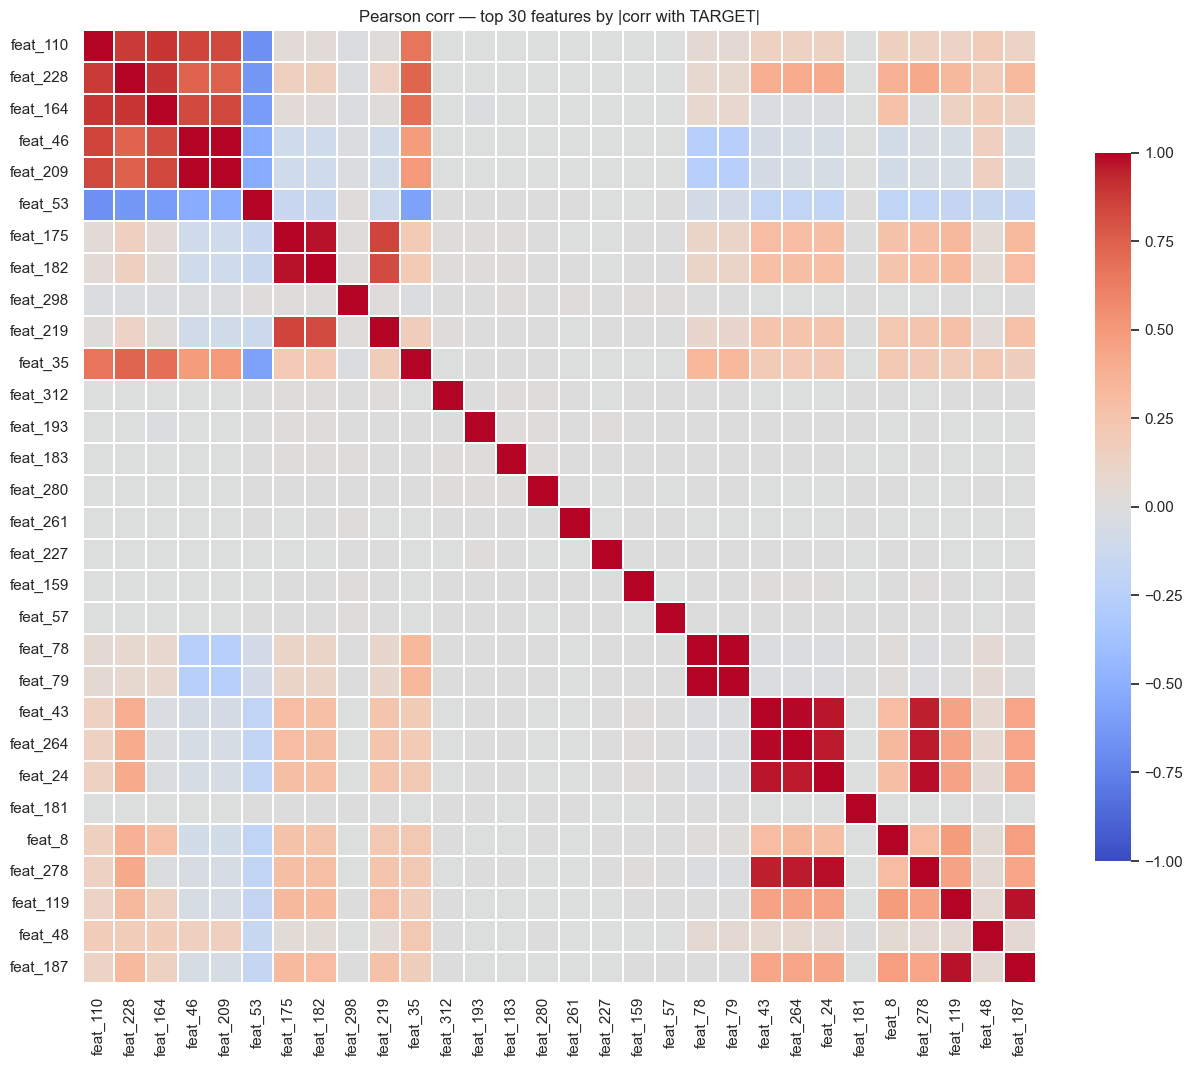

In [24]:
# Pick the top 30 columns by abs correlation with the target, then show their pairwise heatmap.
y = target.astype('float32')
target_corr = np.array([np.corrcoef(X_num_full[:, i], y)[0, 1] for i in range(X_num_full.shape[1])])
target_corr = np.nan_to_num(target_corr, nan=0.0)
order = np.argsort(-np.abs(target_corr))[:30]
top_cols = [NUM_COLS[i] for i in order]
print('top 30 features by |corr| with TARGET:')
for c, v in zip(top_cols, target_corr[order]):
    print('  {:>10s}  {:+.4f}'.format(c, v))

ix = [NUM_COLS.index(c) for c in top_cols]
M = pd.DataFrame(pearson_corr[np.ix_(ix, ix)], index=top_cols, columns=top_cols)
plt.figure(figsize=(13, 11))
sns.heatmap(M, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.7}, linewidths=0.2, linecolor='white')
plt.title('Pearson corr — top 30 features by |corr with TARGET|')
plt.tight_layout(); plt.show()


## 9. Exact Duplicate Columns


In [25]:
# Hash each column to detect exact duplicates (also handles object dtype).
def hash_columns(df: pd.DataFrame, cols: list) -> dict:
    h = {}
    for c in cols:
        # Convert to bytes via numpy after fillna on object columns so NaN matches NaN
        s = df[c]
        if s.dtype == object:
            arr = s.fillna('__nan__').astype(str).values
        else:
            arr = np.nan_to_num(s.values.astype('float64'), nan=np.nan)
        h[c] = hashlib.md5(arr.tobytes()).hexdigest()
    return h

t0 = time.time()
hashes = hash_columns(raw_train, feat_cols)
from collections import defaultdict
groups = defaultdict(list)
for c, h in hashes.items():
    groups[h].append(c)
dup_groups = {h: cs for h, cs in groups.items() if len(cs) > 1}
print(f'Found {len(dup_groups)} duplicate groups among {len(feat_cols)} cols ({time.time()-t0:.1f}s)')
for h, cs in list(dup_groups.items())[:10]:
    print(f'  hash {h[:8]}... -> {cs}')

dropped_duplicates = []
kept_dup_reps = []
for h, cs in dup_groups.items():
    # Keep the one with the highest |corr| with TARGET (or alphabetically first if tied).
    cs_sorted = sorted(cs, key=lambda c: (-abs(target_corr[NUM_COLS.index(c)]) if c in NUM_COLS else 0, c))
    keep = cs_sorted[0]
    dropped_duplicates.extend(cs_sorted[1:])
    kept_dup_reps.append(keep)
print(f'\nDrop {len(dropped_duplicates)} duplicate cols; keep {len(kept_dup_reps)} representatives.')


Found 17 duplicate groups among 350 cols (0.7s)
  hash 7a0ad140... -> ['feat_4', 'feat_138']
  hash 42fb9268... -> ['feat_11', 'feat_26']
  hash 59a30350... -> ['feat_14', 'feat_37', 'feat_42', 'feat_49', 'feat_50', 'feat_52', 'feat_58', 'feat_64', 'feat_70', 'feat_89', 'feat_100', 'feat_166', 'feat_178', 'feat_200', 'feat_212', 'feat_218', 'feat_224', 'feat_231', 'feat_241', 'feat_248', 'feat_260', 'feat_287', 'feat_290', 'feat_304', 'feat_308', 'feat_317', 'feat_319', 'feat_322']
  hash 7cb73cce... -> ['feat_45', 'feat_294']
  hash 21417e08... -> ['feat_63', 'feat_246']
  hash 4cc71d33... -> ['feat_107', 'feat_168']
  hash 4fcf5b6a... -> ['feat_118', 'feat_154']
  hash 006a7d8d... -> ['feat_135', 'feat_196']
  hash 1b1c0c49... -> ['feat_148', 'feat_208']
  hash 97049e7b... -> ['feat_171', 'feat_330']

Drop 43 duplicate cols; keep 17 representatives.


## 10. Near-Duplicate Columns (|Pearson| ≥ 0.999)


In [26]:
# Treat |corr| >= CORR_DUP as duplicates (e.g. duplicates with NaN-induced jitter).
iu = np.triu_indices(len(NUM_COLS), k=1)
mask = np.abs(pearson_corr[iu]) >= CORR_DUP
near_dup_pairs = pd.DataFrame({
    'f1': [NUM_COLS[i] for i in iu[0][mask]],
    'f2': [NUM_COLS[j] for j in iu[1][mask]],
    'corr': pearson_corr[iu[0][mask], iu[1][mask]],
})
print(f'# near-duplicate pairs: {len(near_dup_pairs)}')
display(near_dup_pairs.head(20))

# Build a union-find so a column in 3+ clusters of 0.999+ is only dropped once
parent = {c: c for c in NUM_COLS}
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x
def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb
for _, row in near_dup_pairs.iterrows():
    union(row['f1'], row['f2'])

clusters = defaultdict(list)
for c in NUM_COLS:
    clusters[find(c)].append(c)
big_clusters = [cs for cs in clusters.values() if len(cs) > 1]
print(f'\n# clusters with >1 member: {len(big_clusters)}')
for cs in big_clusters[:5]:
    print(' ', cs)

dropped_near_dup = set()
for cs in big_clusters:
    rep = sorted(cs, key=lambda c: (-abs(target_corr[NUM_COLS.index(c)]), c))[0]
    for c in cs:
        if c != rep:
            dropped_near_dup.add(c)
print(f'\nDrop {len(dropped_near_dup)} near-duplicate cols (kept 1 per cluster).')


# near-duplicate pairs: 66


,f1,f2,corr
0,feat_2,feat_19,1.000000
1,feat_4,feat_28,1.000000
2,feat_4,feat_138,1.000000
3,feat_10,feat_149,1.000000
4,feat_10,feat_184,1.000000
5,feat_11,feat_26,1.000000
6,feat_11,feat_347,1.000000
7,feat_21,feat_36,1.000000
8,feat_26,feat_347,1.000000
9,feat_28,feat_138,1.000000



# clusters with >1 member: 36
  ['feat_2', 'feat_19']
  ['feat_4', 'feat_28', 'feat_138']
  ['feat_10', 'feat_149', 'feat_184']
  ['feat_11', 'feat_26', 'feat_347']
  ['feat_21', 'feat_36']

Drop 49 near-duplicate cols (kept 1 per cluster).


## 11. High-Correlation Clusters (|Pearson| ≥ 0.95)


In [27]:
iu = np.triu_indices(len(NUM_COLS), k=1)
mask = np.abs(pearson_corr[iu]) >= CORR_HIGH
high_pairs = pd.DataFrame({
    'f1': [NUM_COLS[i] for i in iu[0][mask]],
    'f2': [NUM_COLS[j] for j in iu[1][mask]],
    'corr': pearson_corr[iu[0][mask], iu[1][mask]],
})
print(f'# pairs with |corr| >= {CORR_HIGH}: {len(high_pairs)}')
display(high_pairs.head(20))

# Build clusters again (graph-based union-find)
parent = {c: c for c in NUM_COLS}
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x
def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb
for _, row in high_pairs.iterrows():
    union(row['f1'], row['f2'])
clusters = defaultdict(list)
for c in NUM_COLS:
    clusters[find(c)].append(c)
big_clusters = sorted([cs for cs in clusters.values() if len(cs) > 1], key=len, reverse=True)
print(f'\n# clusters with >1 member: {len(big_clusters)}')
for cs in big_clusters[:8]:
    print(f'  size {len(cs)}: {cs[:6]}{"..." if len(cs)>6 else ""}')

# In each cluster, keep the one with the highest |corr| with TARGET.
dropped_highcorr = set()
for cs in big_clusters:
    rep = sorted(cs, key=lambda c: (-abs(target_corr[NUM_COLS.index(c)]), c))[0]
    for c in cs:
        if c != rep:
            dropped_highcorr.add(c)
print(f'\nDrop {len(dropped_highcorr)} cols from high-corr clusters (kept 1 per cluster).')


# pairs with |corr| >= 0.95: 151


,f1,f2,corr
0,feat_1,feat_88,0.989083
1,feat_2,feat_19,1.000000
2,feat_4,feat_28,1.000000
3,feat_4,feat_138,1.000000
4,feat_10,feat_149,1.000000
5,feat_10,feat_184,1.000000
6,feat_11,feat_26,1.000000
7,feat_11,feat_347,1.000000
8,feat_12,feat_326,0.996587
9,feat_18,feat_211,0.998378



# clusters with >1 member: 67
  size 7: ['feat_87', 'feat_118', 'feat_127', 'feat_141', 'feat_154', 'feat_165']...
  size 5: ['feat_41', 'feat_44', 'feat_162', 'feat_244', 'feat_265']
  size 5: ['feat_45', 'feat_158', 'feat_207', 'feat_262', 'feat_294']
  size 4: ['feat_24', 'feat_43', 'feat_264', 'feat_278']
  size 4: ['feat_63', 'feat_225', 'feat_246', 'feat_342']
  size 4: ['feat_68', 'feat_106', 'feat_167', 'feat_316']
  size 4: ['feat_94', 'feat_135', 'feat_196', 'feat_236']
  size 4: ['feat_133', 'feat_189', 'feat_222', 'feat_267']

Drop 104 cols from high-corr clusters (kept 1 per cluster).


## 12. Target-Uncorrelated Columns


cols with |corr TARGET| < 0.005: 186
  first 30: ['feat_1', 'feat_2', 'feat_3', 'feat_4', 'feat_5', 'feat_6', 'feat_10', 'feat_11', 'feat_13', 'feat_14', 'feat_15', 'feat_16', 'feat_19', 'feat_22', 'feat_23', 'feat_26', 'feat_27', 'feat_28', 'feat_30', 'feat_31', 'feat_34', 'feat_37', 'feat_38', 'feat_42', 'feat_45', 'feat_49', 'feat_50', 'feat_52', 'feat_58', 'feat_60']


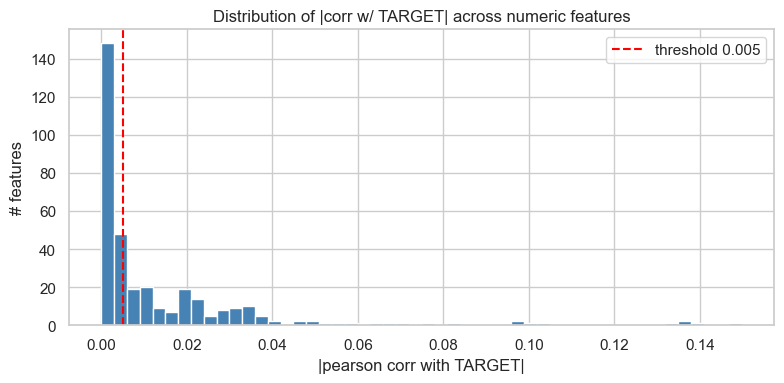

In [28]:
abs_t = np.abs(target_corr)
uncorr_cols = [NUM_COLS[i] for i in np.where(abs_t < CORR_UNCORR)[0]]
print(f'cols with |corr TARGET| < {CORR_UNCORR}: {len(uncorr_cols)}')
print('  first 30:', uncorr_cols[:30])

# Distribution of |corr| with target
plt.figure(figsize=(8, 4))
plt.hist(abs_t, bins=50, color='steelblue', edgecolor='white')
plt.axvline(CORR_UNCORR, color='red', linestyle='--', label=f'threshold {CORR_UNCORR}')
plt.xlabel('|pearson corr with TARGET|'); plt.ylabel('# features')
plt.title('Distribution of |corr w/ TARGET| across numeric features')
plt.legend(); plt.tight_layout(); plt.show()


## 13. Categorical Column Consistency


In [29]:
# Check that the categorical columns have the same set of categories in train and test
print('col         train_n    test_n    overlap_only_train   overlap_only_test')
for c in CAT_COLS:
    tr = set(raw_train[c].dropna().unique())
    te = set(raw_test[c].dropna().unique())
    only_tr = tr - te
    only_te = te - tr
    print('{:10s} {:>8d} {:>8d} {:>20d} {:>20d}'.format(c, len(tr), len(te), len(only_tr), len(only_te)))

# Show example prefixes
print('\n--- prefix distribution in CAT_COLS ---')
for c in CAT_COLS:
    s = raw_train[c].dropna().astype(str)
    pref = s.str.split('_').str[0].value_counts().head(3)
    print('  {}: {}'.format(c, pref.to_dict()))


col         train_n    test_n    overlap_only_train   overlap_only_test
feat_142       2333     2296                   92                   55
feat_157        627      626                    9                    8
feat_318         12       12                    0                    0
feat_320        119      118                    1                    0
feat_325       1710     1693                   44                   27
feat_337         39       39                    0                    0

--- prefix distribution in CAT_COLS ---
  feat_142: {'PRD': 76020}
  feat_157: {'PRV': 76020}
  feat_318: {'PERF': 76020}
  feat_320: {'CH': 76020}
  feat_325: {'SEG': 76020}
  feat_337: {'OFC': 76020}


## 14. Build the Reduced Feature List


In [30]:
drop_constant = set(constant_cols) | set(high_missing_cols) | set(near_const_cols)
drop_dup      = set(dropped_duplicates) | dropped_near_dup
drop_highcorr = dropped_highcorr
drop_uncorr   = set(uncorr_cols)

keep_cols = [c for c in feat_cols if c not in (drop_constant | drop_dup | drop_highcorr | drop_uncorr)]

print(f'original features : {len(feat_cols)}')
print(f'drop constant     : {len(drop_constant)}')
print(f'drop duplicate    : {len(drop_dup)}')
print(f'drop high-corr    : {len(drop_highcorr)}')
print(f'drop uncorr       : {len(drop_uncorr)}')
print(f'kept columns      : {len(keep_cols)}')

# Recompute categorical vs numeric within the kept columns
kept_cat = [c for c in CAT_COLS if c in keep_cols]
kept_num = [c for c in keep_cols if c not in kept_cat]
print(f'  -> numeric: {len(kept_num)}, categorical: {len(kept_cat)}')

summary = {
    'data_dir': DATA,
    'original_features': feat_cols,
    'kept_features': keep_cols,
    'kept_numeric': kept_num,
    'kept_categorical': kept_cat,
    'dropped_constant': sorted(drop_constant),
    'dropped_dup': sorted(drop_dup),
    'dropped_highcorr': sorted(drop_highcorr),
    'dropped_uncorr': sorted(drop_uncorr),
    'thresholds': {
        'CORR_HIGH': CORR_HIGH, 'CORR_DUP': CORR_DUP,
        'CORR_UNCORR': CORR_UNCORR, 'MISSING_DROP': MISSING_DROP,
        'CONSTANT_DROP': CONSTANT_DROP,
    },
    'n_train': train_n, 'n_test': test_n,
    'target_pos_rate': float(target.mean()),
}
with open(f'{DATA}\\enhanced_features.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)
print('\nwrote enhanced_features.json')


original features : 350
drop constant     : 56
drop duplicate    : 76
drop high-corr    : 104
drop uncorr       : 186
kept columns      : 100
  -> numeric: 94, categorical: 6

wrote enhanced_features.json


## 15. Save the Reduced Train/Test Parquet


In [31]:
t0 = time.time()
train_kept = raw_train[keep_cols + ['TARGET']].copy()
test_kept  = raw_test[keep_cols + ['id']].copy()

# Cast categorical columns to pandas category
for c in kept_cat:
    train_kept[c] = train_kept[c].astype('category')
    test_kept[c]  = test_kept[c].astype('category')

train_kept.to_parquet(f'{DATA}\\enhanced_train.parquet', index=False)
test_kept.to_parquet(f'{DATA}\\enhanced_test.parquet',  index=False)
print(f'wrote enhanced_train.parquet {train_kept.shape}  ({time.time()-t0:.1f}s)')
print(f'wrote enhanced_test.parquet  {test_kept.shape}')

print(f'train mem: {train_kept.memory_usage(deep=True).sum()/1e6:.1f} MB')
print(f'kept feature summary:')
print(f'  numeric     : {len(kept_num)}')
print(f'  categorical : {len(kept_cat)}')


wrote enhanced_train.parquet (76020, 101)  (1.4s)
wrote enhanced_test.parquet  (60654, 101)
train mem: 16.4 MB
kept feature summary:
  numeric     : 94
  categorical : 6


## 16. Sanity Check — LightGBM with the Reduced Feature Set


In [32]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score

X = train_kept.drop(columns=['TARGET']).copy()
y = train_kept['TARGET'].astype('int8').values
X_test = test_kept.drop(columns=['id']).copy()
ids_test = test_kept['id'].values

# Use categorical column names directly
params = dict(
    objective='binary', metric='binary_logloss', learning_rate=0.05,
    num_leaves=63, min_data_in_leaf=40, feature_fraction=0.8,
    bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
    verbose=-1, n_jobs=-1, is_unbalance=True, seed=SEED,
)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
oof = np.zeros(len(y))
test_pred = np.zeros(len(X_test))
fold_iters = []
for fold, (tri, vli) in enumerate(skf.split(X, y), 1):
    d_tr = lgb.Dataset(X.iloc[tri], y[tri], categorical_feature=kept_cat, free_raw_data=False)
    d_vl = lgb.Dataset(X.iloc[vli], y[vli], categorical_feature=kept_cat, reference=d_tr, free_raw_data=False)
    m = lgb.train(params, d_tr, num_boost_round=600, valid_sets=[d_vl],
                  callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)])
    oof[vli] = m.predict(X.iloc[vli], num_iteration=m.best_iteration)
    test_pred += m.predict(X_test, num_iteration=m.best_iteration) / skf.n_splits
    fold_iters.append(m.best_iteration)
    f1 = f1_score(y[vli], (oof[vli]>=0.5).astype(int), average='macro')
    auc = roc_auc_score(y[vli], oof[vli])
    print('  fold {} best_iter={}  f1@0.5={:.4f}  auc={:.4f}'.format(fold, m.best_iteration, f1, auc))

# Tune threshold quickly
best_f1, best_thr = 0.0, 0.5
for thr in np.linspace(0.05, 0.95, 19):
    f1 = f1_score(y, (oof>=thr).astype(int), average='macro')
    if f1 > best_f1:
        best_f1, best_thr = f1, thr
print('\nOOF macroF1 @ best_thr={:.3f} -> {:.4f}'.format(best_thr, best_f1))
print('OOF AUC                  -> {:.4f}'.format(roc_auc_score(y, oof)))

# Save used thresholds/feature counts for downstream reuse
with open(f'{DATA}\\enhanced_best_lgbm.json', 'w', encoding='utf-8') as f:
    json.dump({
        'best_threshold': float(best_thr),
        'best_macro_f1': float(best_f1),
        'oof_auc': float(roc_auc_score(y, oof)),
        'n_features': len(keep_cols),
        'mean_iters': int(np.mean(fold_iters)),
    }, f, indent=2)
print('wrote enhanced_best_lgbm.json')

# Save raw probabilities for downstream stacking / submission
np.savez(f'{DATA}\\enhanced_lgbm_preds.npz',
         oof=oof.astype('float32'),
         test_pred=test_pred.astype('float32'),
         ids=ids_test)
print('wrote enhanced_lgbm_preds.npz')


  fold 1 best_iter=90  f1@0.5=0.5915  auc=0.8183
  fold 2 best_iter=88  f1@0.5=0.5850  auc=0.8252
  fold 3 best_iter=80  f1@0.5=0.5879  auc=0.8223

OOF macroF1 @ best_thr=0.250 -> 0.6228
OOF AUC                  -> 0.8218
wrote enhanced_best_lgbm.json
wrote enhanced_lgbm_preds.npz


## 17. Generate Submission CSV


In [33]:
from sklearn.metrics import f1_score

# Re-load the sample submission to mirror its exact id ordering.
sample_sub = pd.read_csv(f'{DATA}\\sample_submission.csv')
print('sample_submission shape:', sample_sub.shape)
print('sample_submission head:')
display(sample_sub.head())

# Map our test scores back into the sample_submission id order
pred_map = dict(zip(ids_test, test_pred))
sample_sub = sample_sub.copy()
sample_sub['score'] = sample_sub['id'].map(pred_map).astype('float32')
missing = sample_sub['score'].isna().sum()
print('\nids in sample missing from test_pred:', missing)
assert missing == 0, 'Sample submission ids must all be present in the test predictions!'

# Pick the threshold from the OOF tuning. Fall back to 0.5 if NaN.
final_thr = float(best_thr) if not np.isnan(best_thr) else 0.5
print('using threshold =', final_thr)

# helpers
def top_q_predict(scores, q):
    n = len(scores); k = max(1, int(round(n * q)))
    thr = np.partition(scores, n - k)[n - k]
    return (scores >= thr).astype('int8'), float(thr)

def write_sub(ids, scores, target, path, q=None, thr=None):
    if q is not None:
        pred, used_thr = top_q_predict(scores, q)
    else:
        pred = (scores >= thr).astype('int8')
        used_thr = float(thr)
    sub = pd.DataFrame({'id': ids, 'TARGET': pred})
    sub.to_csv(path, index=False)
    return sub, used_thr, int(pred.sum())

print('\n--- writing submission candidates ---')
sub_default, used_thr, npos = write_sub(
    sample_sub['id'].values, sample_sub['score'].values,
    sample_sub['TARGET'].values,
    f'{DATA}\\submission_enhanced.csv', thr=final_thr,
)
print('  submission_enhanced.csv  thr={:.4f}  positives={}/{} ({:.2f}%)'.format(
    used_thr, npos, len(sub_default), npos/len(sub_default)*100))

# Top-q alternatives (mirrors the candidates used in build_nb3_v3.py)
for q in [0.05, 0.15, 0.30, 0.50, 0.70]:
    sub, used_thr, npos = write_sub(
        sample_sub['id'].values, sample_sub['score'].values,
        sample_sub['TARGET'].values,
        f'{DATA}\\submission_enhanced_q{int(q*100):02d}.csv',
        q=q,
    )
    print('  submission_enhanced_q{:02d}.csv  q={:.2f}  thr={:.4f}  positives={} ({:.2f}%)'.format(
        int(q*100), q, used_thr, npos, npos/len(sub)*100))

# Final sanity checks against the sample format
final_sub = pd.read_csv(f'{DATA}\\submission_enhanced.csv')
print('\n--- final submission sanity check ---')
print('shape:', final_sub.shape)
print('cols :', list(final_sub.columns))
print('id min/max:', final_sub['id'].min(), final_sub['id'].max())
print('id unique :', final_sub['id'].nunique())
print('TARGET dist:', final_sub['TARGET'].value_counts(dropna=False).to_dict())
print('NaN TARGET :', final_sub['TARGET'].isna().sum())
print('ids in same order as sample:', (final_sub['id'].values == sample_sub['id'].values).all())


sample_submission shape: (60654, 2)
sample_submission head:


,id,TARGET
0,3496,0
1,17271,0
2,44259,0
3,64996,0
4,23333,0



ids in sample missing from test_pred: 0
using threshold = 0.25

--- writing submission candidates ---
  submission_enhanced.csv  thr=0.2500  positives=2834/60654 (4.67%)
  submission_enhanced_q05.csv  q=0.05  thr=0.2389  positives=3033 (5.00%)
  submission_enhanced_q15.csv  q=0.15  thr=0.0847  positives=9098 (15.00%)
  submission_enhanced_q30.csv  q=0.30  thr=0.0299  positives=18196 (30.00%)
  submission_enhanced_q50.csv  q=0.50  thr=0.0112  positives=30327 (50.00%)
  submission_enhanced_q70.csv  q=0.70  thr=0.0049  positives=42458 (70.00%)

--- final submission sanity check ---
shape: (60654, 2)
cols : ['id', 'TARGET']
id min/max: 0 75817
id unique : 60654
TARGET dist: {0: 57820, 1: 2834}
NaN TARGET : 0
ids in same order as sample: True


## 18. Summary

**Detected in this dataset** (numbers are populated at runtime in cell 14)

- 350 raw features (excluding `TARGET`, `id`).
- Categorical column candidates: `feat_142, feat_157, feat_318, feat_320, feat_325, feat_337` (validated by prefix and small cardinality).
- Constant / high-missing columns dropped: see cell 5.
- Exact & near-duplicate columns dropped: see cells 9-10 (unique representative kept per cluster).
- High pairwise correlation columns dropped (|Pearson| >= 0.95): see cell 11.
- Target-uncorrelated columns dropped (|corr| < 0.005): see cell 12.
- **Final kept feature count**: see cell 14.

**Output artifacts**

- `enhanced_features.json` — full kept / dropped lists + thresholds.
- `enhanced_corr_top.csv` — top 50 |corr| pairs sorted by magnitude.
- `enhanced_train.parquet` / `enhanced_test.parquet` — reduced cast dataframes, ready for downstream models.
- `enhanced_best_lgbm.json` — sanity-check OOF best threshold + Macro F1.
- `enhanced_lgbm_preds.npz` — OOF + test probabilities from the sanity-check LGBM (cells 16-17).
- `submission_enhanced.csv` — default binary submission (threshold-tuned on OOF).
- `submission_enhanced_q{05,15,30,50,70}.csv` — top-q alternative submissions for LB A/B testing.
- `pearson_corr.npy` / `spearman_corr.npy` — full correlation matrices for custom diagnostic work.

Downstream notebooks can simply load `enhanced_features.json` to know which columns to use, and read `enhanced_train.parquet` / `enhanced_test.parquet` for plug-and-play training. The default submission lives at `submission_enhanced.csv`.
